In [1]:
import sys
import os
import pandas as pd

# Direct python to see the source root directory 
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import InsuranceDataLoader
from src.eda_utils import InsuranceEDAVisualizer

# Fire data loading engine
loader = InsuranceDataLoader(file_path="../data/MachineLearningRating_v3.txt")
df = loader.load_and_initialize()

print(f"✅ Data Matrix Successfully Loaded.")
print(f"Total Rows: {df.shape[0]:,} | Total Features: {df.shape[1]}")

✅ Data Matrix Successfully Loaded.
Total Rows: 1,000,098 | Total Features: 54


In [3]:
# Compute global portfolio loss metrics
total_p = df['TotalPremium'].sum()
total_c = df['TotalClaims'].sum()
global_lr = total_c / total_p

print(f"🎯 Portfolio Overall Loss Ratio: {global_lr:.4f} ({global_lr * 100:.2f}%)\n")

# Evaluate metrics variance across target categorical dimensions
for feature in ['Province', 'VehicleType', 'Gender']:
    print(f"--- Performance Variance across {feature} ---")
    grouped = df.groupby(feature).agg(
        Total_Premium=('TotalPremium', 'sum'),
        Total_Claims=('TotalClaims', 'sum')
    ).reset_index()
    grouped['Loss_Ratio'] = grouped['Total_Claims'] / grouped['Total_Premium']
    print(grouped.sort_values(by='Loss_Ratio', ascending=False).to_string(index=False))
    print("\n")

🎯 Portfolio Overall Loss Ratio: 1.0477 (104.77%)

--- Performance Variance across Province ---
     Province  Total_Premium  Total_Claims  Loss_Ratio
      Gauteng   2.405377e+07  2.939415e+07    1.222018
KwaZulu-Natal   1.320908e+07  1.430138e+07    1.082693
 Western Cape   9.806559e+06  1.038977e+07    1.059472
   North West   7.490508e+06  5.920250e+06    0.790367
   Mpumalanga   2.836292e+06  2.044675e+06    0.720897
   Free State   5.213632e+05  3.549223e+05    0.680758
      Limpopo   1.537324e+06  1.016477e+06    0.661199
 Eastern Cape   2.140104e+06  1.356427e+06    0.633813
Northern Cape   3.165581e+05  8.949051e+04    0.282699


--- Performance Variance across VehicleType ---
      VehicleType  Total_Premium  Total_Claims  Loss_Ratio
 Heavy Commercial   4.609479e+05  7.504746e+05    1.628112
Medium Commercial   3.922746e+06  4.119867e+06    1.050251
Passenger Vehicle   5.664202e+07  5.937207e+07    1.048198
 Light Commercial   2.604975e+05  6.045250e+04    0.232066
          

Plotting Total Claims outliers...


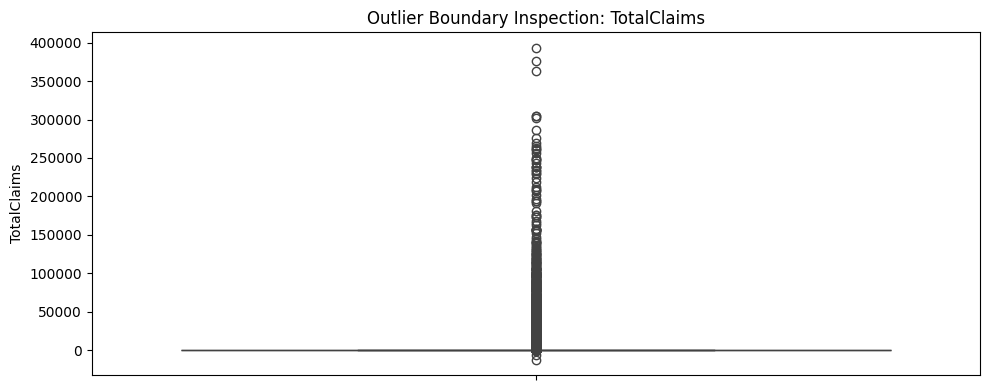

Plotting Total Premium outliers...


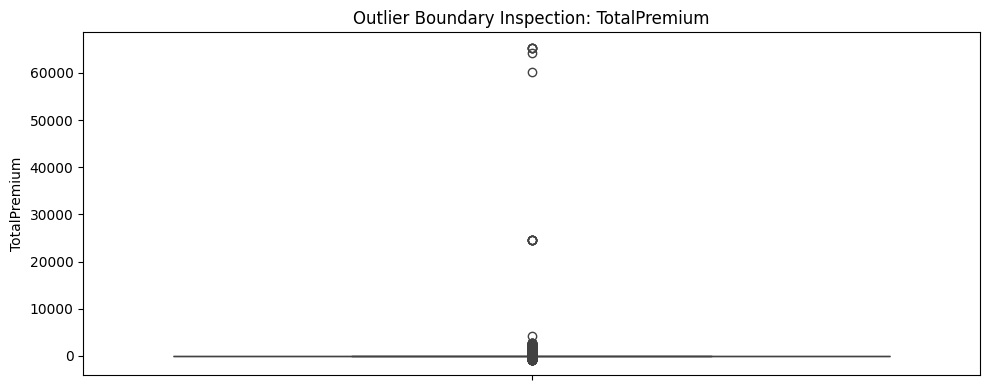

In [4]:
visualizer = InsuranceEDAVisualizer()

# Inspect severity limits
print("Plotting Total Claims outliers...")
visualizer.plot_outlier_boxplot(df, column='TotalClaims')

# Inspect premium volume limits
print("Plotting Total Premium outliers...")
visualizer.plot_outlier_boxplot(df, column='TotalPremium')

In [5]:
# Extract chronological time brackets
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')

# Group temporal operational matrices
temporal_summary = df.groupby('YearMonth').agg(
    Active_Policies=('PolicyID', 'count'),
    Total_Claims_Paid=('TotalClaims', 'sum'),
    Claim_Frequency=('TotalClaims', lambda x: (x > 0).mean()), # % of policies with claims
    Claim_Severity=('TotalClaims', lambda x: x[x > 0].mean())   # Avg claim size when it happens
).reset_index()

print("📈 18-Month Chronological Insurance Risk Log:")
print(temporal_summary.to_string(index=False))

📈 18-Month Chronological Insurance Risk Log:
YearMonth  Active_Policies  Total_Claims_Paid  Claim_Frequency  Claim_Severity
  2013-10               45       0.000000e+00         0.000000             NaN
  2013-11             1196       5.058508e+04         0.001672    25292.539474
  2013-12             1495       9.283386e+03         0.002007     3094.461988
  2014-01             1827       1.243686e+04         0.001095     6218.429825
  2014-02             2062       6.298931e+04         0.002910    10498.217836
  2014-03             3466       3.227850e+05         0.003462    26898.751798
  2014-04             6919       3.068636e+05         0.002891    15343.179605
  2014-05             9484       5.180427e+05         0.002952    18513.253095
  2014-06            11822       5.045364e+05         0.002368    18019.157018
  2014-07            14907       4.289822e+05         0.001811    15911.766699
  2014-08            19626       6.934197e+05         0.002599    13831.806330
  2014-

In [6]:
# Group vehicle records
asset_risk = df.groupby(['make', 'Model']).agg(
    Aggregate_Claims=('TotalClaims', 'sum'),
    Total_Incidents=('TotalClaims', lambda x: (x > 0).sum()),
    Mean_Severity=('TotalClaims', lambda x: x[x > 0].mean())
).reset_index()

# Filter for a sample size of at least 15 incidents to remove one-off anomalies
credible_assets = asset_risk[asset_risk['Total_Incidents'] >= 15]

print("🚨 TOP 5 HIGHEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:")
print(credible_assets.sort_values(by='Aggregate_Claims', ascending=False).head(5).to_string(index=False))

print("\n💎 BOTTOM 5 LOWEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:")
print(credible_assets.sort_values(by='Aggregate_Claims', ascending=True).head(5).to_string(index=False))

🚨 TOP 5 HIGHEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:
  make                          Model  Aggregate_Claims  Total_Incidents  Mean_Severity
TOYOTA      QUANTUM 2.7 SESFIKILE 16s      1.203750e+07              500   24099.011847
TOYOTA      QUANTUM 2.7 SESFIKILE 15s      1.151173e+07              574   20065.200200
TOYOTA      QUANTUM 2.7 SESFIKILE 14s      9.967764e+06              454   21956.827741
TOYOTA QUANTUM 2.5 D-4D SESFIKILE 16s      7.733236e+06              266   29072.315308
TOYOTA          HiACE SUPER 16 F/Lift      3.275205e+06              173   18931.820223

💎 BOTTOM 5 LOWEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:
  make                          Model  Aggregate_Claims  Total_Incidents  Mean_Severity
TOYOTA                  AVANZA 1.3 SX     291370.588947               15   19424.705930
TOYOTA       COROLLA 1.3 PROFESSIONAL     294750.535088               18   16375.029727
JINBEI                     HAISE 2.2i     340789.587719               22   15490.435805
TOYOTA QU